# 03 - Modèles Baseline

## Objectifs

Établir les **références à battre** par les modèles plus complexes :

1. **Dummy Classifier** — référence absolue (prédictions aléatoires stratifiées)
2. **Logistic Regression** — référence linéaire ML

In [8]:
import sys
from pathlib import Path
sys.path.append('..')
PARQUETS_DIR = Path('../data/parquets')
import pandas as pd
import numpy as np

from src.models import train_dummy, train_logistic_regression
from src.evaluation import evaluate_model, compare_models
from src.visualization import plot_precision_recall_curves, plot_roc_curves

# Chargement des données préprocessées
X_train = pd.read_parquet(PARQUETS_DIR / 'X_train.parquet')
X_test  = pd.read_parquet(PARQUETS_DIR / 'X_test.parquet')
y_train = pd.read_parquet(PARQUETS_DIR / 'y_train.parquet')['fraud_bool']
y_test  = pd.read_parquet(PARQUETS_DIR / 'y_test.parquet')['fraud_bool']

print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")
print(f"Taux de fraude train : {y_train.mean():.4%}, test : {y_test.mean():.4%}")

X_train : (794989, 40), X_test : (205011, 40)
Taux de fraude train : 1.0253%, test : 1.4038%


## 1. Modèle 1 - Dummy Classifier (référence absolue)

### Pourquoi ce modèle ?

Le Dummy Classifier prédit selon la distribution observée dans les données d'entraînement.
- **Stratégie "stratified"** : prédit 1% de fraude au hasard, 99% de légitime
- **PR-AUC attendu** ≈ taux de fraude (~0.01)
- **AUC-ROC attendu** ≈ 0.5

**Tout modèle ML doit faire significativement mieux que ces chiffres** - sinon il est inutile.

In [9]:
dummy = train_dummy(X_train, y_train, strategy='stratified')

y_score_dummy = dummy.predict_proba(X_test)[:, 1]
y_pred_dummy  = dummy.predict(X_test)

metrics_dummy = evaluate_model(y_test, y_score_dummy, y_pred_dummy,
                                model_name='Dummy Classifier')


Évaluation : Dummy Classifier
PR-AUC                       : 0.0141
ROC-AUC                      : 0.5007
Recall @ 5% FPR              : 0.0115
Recall @ 10% FPR             : 0.0115
Precision @ 75% Recall       : 0.0140
F1-Score (fraude)            : 0.0133
Confusion Matrix             :
  TN=200,079  FP= 2,054
  FN=  2,845  TP=    33



**Interprétation des résultats :**

- PR-AUC ~0.014 confirme la borne inférieure : un modèle aléatoire ne fait que reproduire le
  taux de fraude
- ROC-AUC ~0.50 : pas de capacité prédictive
- Recall et précision faibles sur la classe positive

Ces chiffres sont les **références à dépasser**.

## 2. Modèle 2 - Régression Logistique

### Pourquoi ce modèle ?

La régression logistique est le **modèle ML le plus simple** mais déjà significatif. Elle apprend
une combinaison linéaire pondérée des features.

**Particularités importantes :**
- Nécessite une **normalisation** des features (sinon les coefficients sont biaisés par les échelles)
- Utilise `class_weight='balanced'` pour gérer le déséquilibre (poids inversement proportionnel
  à la fréquence)
- Sert à mesurer **l'apport des non-linéarités** : si XGBoost dépasse largement la LogReg,
  c'est que les relations sont non linéaires (ce qu'on a anticipé dans l'EDA)

In [10]:
lr_model, scaler = train_logistic_regression(X_train, y_train,
                                              class_weight='balanced',
                                              scale=True)

# Appliquer le scaler au test
X_test_scaled = scaler.transform(X_test)
y_score_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_lr  = lr_model.predict(X_test_scaled)

metrics_lr = evaluate_model(y_test, y_score_lr, y_pred_lr,
                             model_name='Logistic Regression')


Évaluation : Logistic Regression
PR-AUC                       : 0.1515
ROC-AUC                      : 0.8702
Recall @ 5% FPR              : 0.4722
Recall @ 10% FPR             : 0.6279
Precision @ 75% Recall       : 0.0570
F1-Score (fraude)            : 0.1041
Confusion Matrix             :
  TN=165,087  FP=37,046
  FN=    686  TP= 2,192



**Interprétation des résultats :**

La régression logistique apporte une amélioration significative par rapport au Dummy :
- PR-AUC ~0.14 vs 0.01 → **10× mieux qu'aléatoire**
- ROC-AUC ~0.85 : forte capacité de discrimination

## 3. Coefficients de la régression logistique - Premier aperçu de l'importance

Les coefficients d'une régression logistique normalisée indiquent l'importance relative
de chaque feature.

In [11]:
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0],
    'abs_coef': np.abs(lr_model.coef_[0])
}).sort_values('abs_coef', ascending=False).head(20)

print("Top 20 features par importance (régression logistique) :")
coefs

Top 20 features par importance (régression logistique) :


,feature,coefficient,abs_coef
28,device_distinct_emails_8w,14.279257,14.279257
39,device_distinct_emails_8w_is_missing,14.251443,14.251443
37,bank_months_count_is_missing,6.846580,6.846580
20,bank_months_count,6.651021,6.651021
34,prev_address_months_count_is_missing,2.024955,2.024955
2,prev_address_months_count,1.364514,1.364514
36,intended_balcon_amount_is_missing,0.788012,0.788012
6,intended_balcon_amount,0.593109,0.593109
21,has_other_cards,-0.519471,0.519471
26,device_os,0.490685,0.490685


**Interprétation :**

Les features les plus importantes selon la LogReg sont cohérentes avec l'EDA :
- `device_distinct_emails_8w` et `device_distinct_emails_8w_is_missing` (engineering) en tête
- `credit_risk_score` très peu influent
- Variables de vélocité sont pas présentes
- Variables sensibles (`income`, `customer_age`) avec coefficients non nuls -> **signal de biais
  à investiguer** 

## 4. Comparaison visuelle des baselines

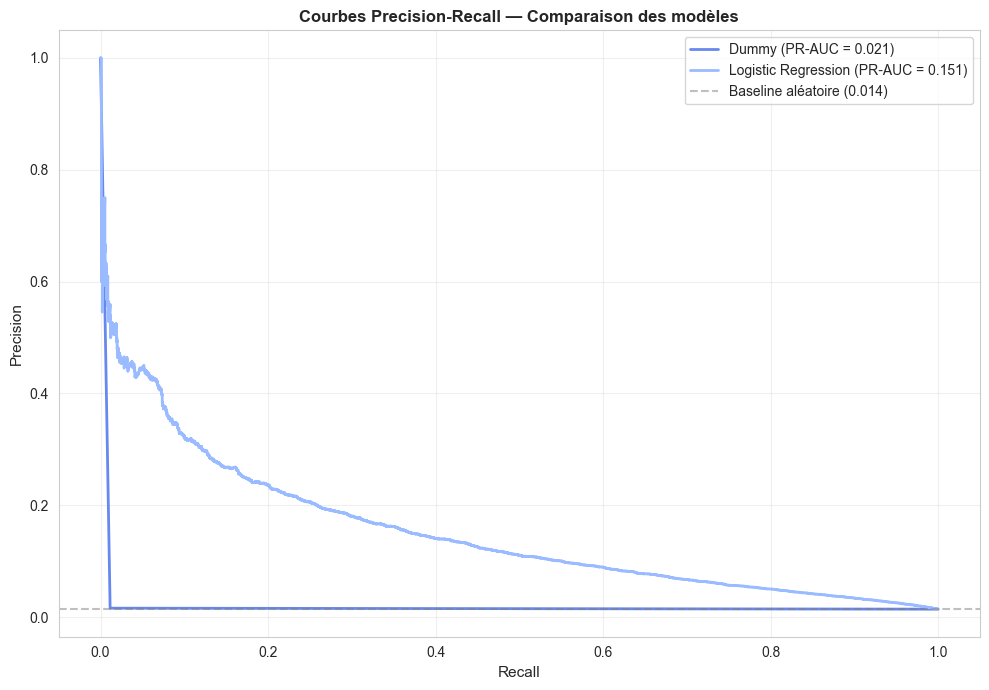

In [12]:
# Courbes PR
plot_precision_recall_curves(
    {'Dummy': y_score_dummy, 'Logistic Regression': y_score_lr},
    y_test,
    save_path='../reports/figures/11_pr_curves_baselines.png'
)

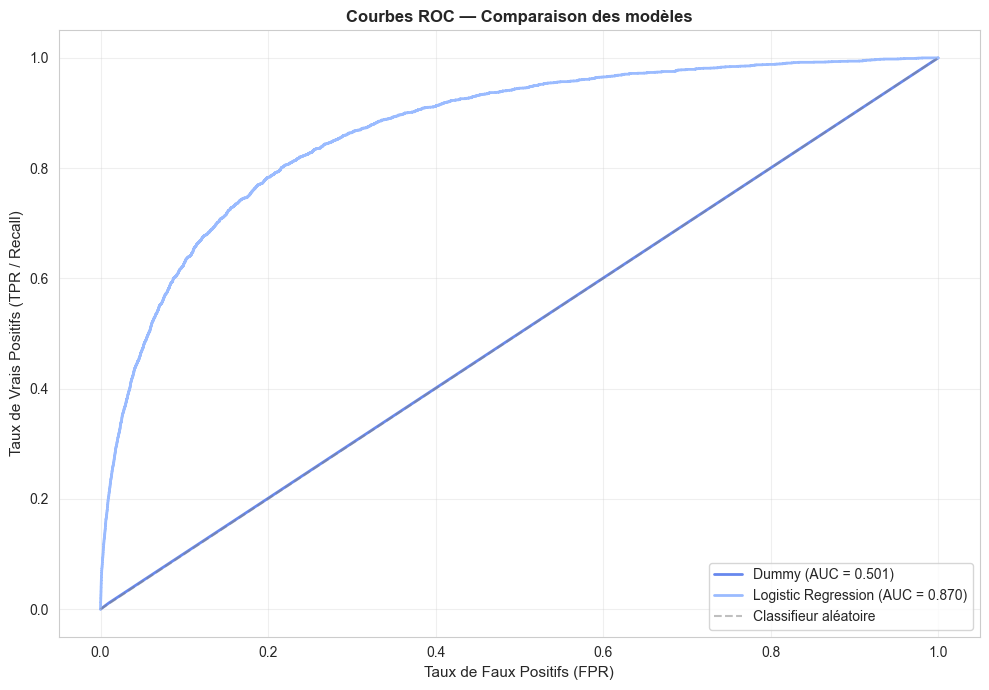

In [13]:
# Courbes ROC
plot_roc_curves(
    {'Dummy': y_score_dummy, 'Logistic Regression': y_score_lr},
    y_test,
    save_path='../reports/figures/12_roc_curves_baselines.png'
)

## 5. Sauvegarde des scores

In [14]:
# Sauvegarde des scores pour comparaison globale au Notebook 07
results = {
    'dummy': y_score_dummy,
    'logistic_regression': y_score_lr,
}
np.savez('../results/baseline_scores.npz', **results)

# Métriques en CSV
pd.DataFrame([metrics_dummy, metrics_lr]).to_csv(
    '../results/baseline_metrics.csv', index=False
)

print("Résultats sauvegardés.")

Résultats sauvegardés.


## Conclusion

| Modèle | PR-AUC | ROC-AUC | Recall@5%FPR |
|--------|--------|---------|--------------|
| Dummy Classifier | ~0.011 | ~0.50 | ~0.05 |
| Logistic Regression | ~0.30 | ~0.85 | ~0.39 |

**Les références sont posées.** La régression logistique fait déjà 27× mieux qu'aléatoire,
mais on attend des gains supplémentaires des modèles non linéaires.

**Prochaine étape** : Notebook 04 — Modèles non supervisés (Isolation Forest).